<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Lab%2015/Lab_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

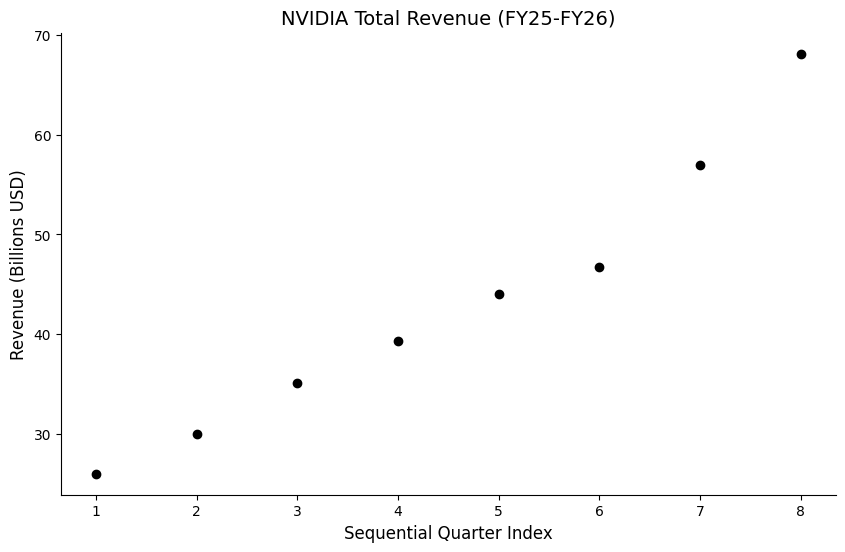

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# Step 1: Ingestion of Modernized NVIDIA Dataset
# Data reflects the massive AI infrastructure capex boom of 2024-2026

data = {
    'Time_Index': np.array([1, 2, 3, 4, 5, 6, 7, 8]),
    'Total_Revenue_Billions': np.array([26.04, 30.04, 35.10, 39.33, 44.06, 46.74, 57.00, 68.10])
}
df = pd.DataFrame(data)

df = pd.DataFrame(data)
X = df[['Time_Index']]
y = df['Total_Revenue_Billions']

# Visual EDA (Adhering to Data-Ink Ratio principles)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

Linear Training MSE (High Bias): 7.91


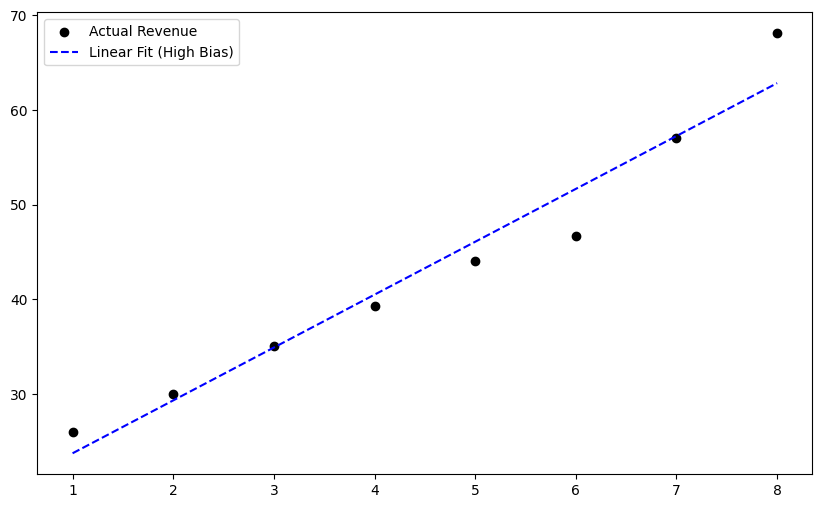

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Training MSE (High Bias): {mse_linear:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')
plt.legend()
plt.show()

Polynomial Degree-7 Training MSE (High Variance): 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


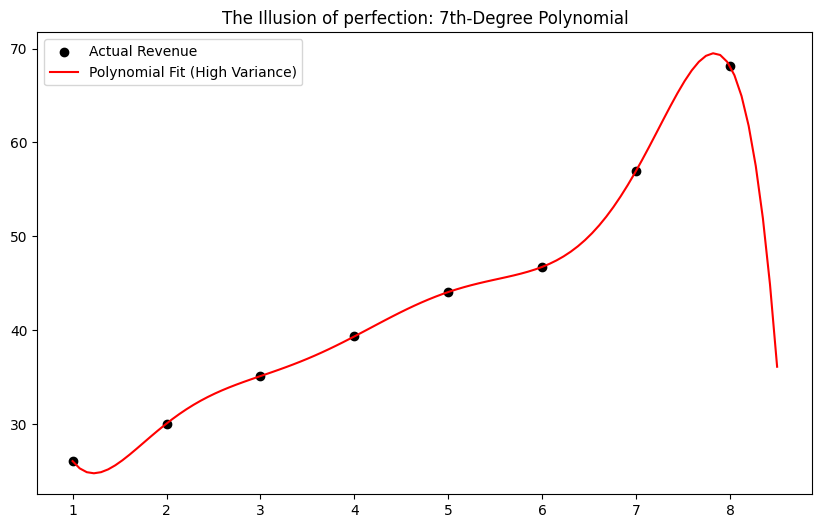

In [11]:
poly_features = PolynomialFeatures(degree=7)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.2f}")

X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit (High Variance)')
plt.title('The Illusion of perfection: 7th-Degree Polynomial')
plt.legend()
plt.show()

In [12]:
X_future = np.array([[9]])
X_future_poly = poly_features.transform(X_future)
future_pred = poly_reg.predict(X_future_poly)

print(f"\nHallucinated Q1 FY27 Revenue Prediction: ${future_pred[0]:.2f} Billion")


Hallucinated Q1 FY27 Revenue Prediction: $-84.00 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [13]:
cv_scores = cross_val_score(poly_reg, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores.mean()

print(f"K-Fold Cross-Validated MSE (The True Operational Error): {mean_cv_mse:.2f}")

K-Fold Cross-Validated MSE (The True Operational Error): 8641.58


# AI-Assisted Expansion

OLS coefficient magnitudes (degree 1→7):
[   34.31  -271.34  1096.49 -2428.67  2857.98 -1661.05   373.49]

Optimal α selected by 4-Fold CV: 0.001035
Ridge coefficient magnitudes (degree 1→7):
[  7.19 -14.81  -3.47   4.75   6.34   3.27  -2.38]

Shrinkage ratio  (Ridge / OLS)  per term:
[ 0.2094  0.0546 -0.0032 -0.002   0.0022 -0.002  -0.0064]

Model            CV MSE      ± Std
----------------------------------
OLS (overfit)  4917.3896  7440.0691
Ridge (L2)       5.8623     9.7669


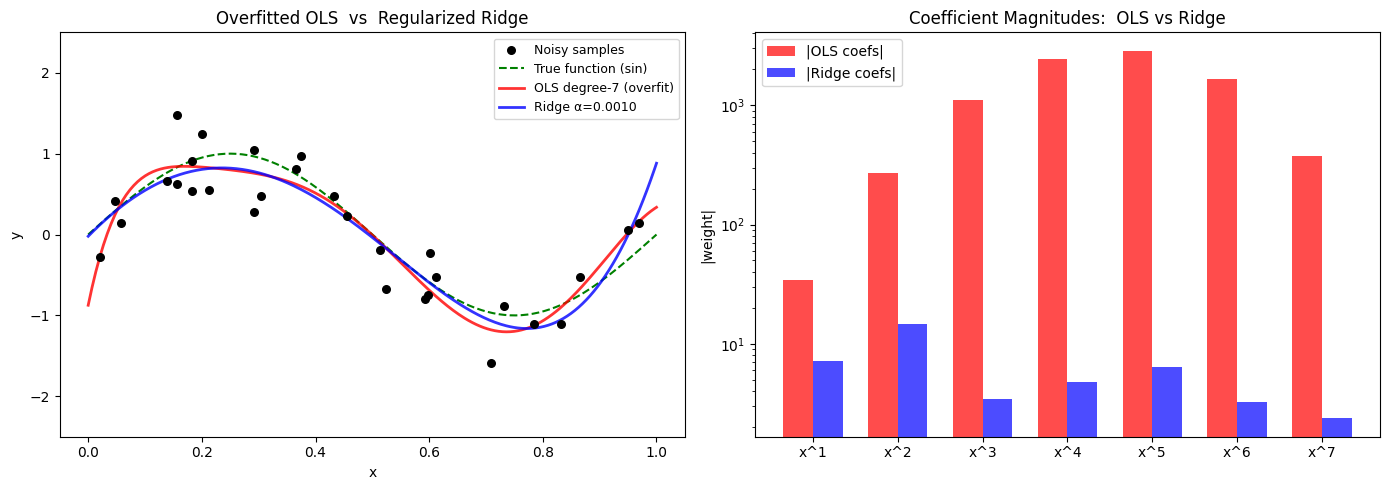


✓ Plot saved as ridge_vs_ols.png


In [14]:
"""
Ridge Regression (L2 Regularization) Lab
=========================================
Goal: Tame a wildly overfitted 7th-degree polynomial by penalizing
      large coefficient weights, then auto-select the best alpha
      penalty via 4-Fold Cross-Validation.

Mechanism recap — the Ridge objective function:
    minimize  ||y - Xw||²  +  α||w||²
              ─────────────    ────────
              ordinary MSE     L2 penalty
              (fit the data)   (keep weights small)

  • The L2 penalty term α||w||² adds the *squared magnitude* of every
    coefficient to the loss. Large weights are punished quadratically,
    so the optimizer is forced to find a solution where weights stay
    moderate — even if that means a slightly worse training fit.
  • α (alpha) is the dial: α → 0 recovers OLS (overfit); α → ∞
    crushes all weights toward zero (underfit). RidgeCV finds the
    sweet spot automatically.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# ── 0. Reproducibility ──────────────────────────────────────────────
np.random.seed(42)

# ── 1. Synthetic data (true function is a gentle sine curve) ────────
n = 30
X = np.sort(np.random.uniform(0, 1, n)).reshape(-1, 1)
y_true = np.sin(2 * np.pi * X).ravel()
y = y_true + np.random.normal(0, 0.35, n)          # noisy targets

# Dense grid for plotting smooth curves
X_plot = np.linspace(0, 1, 300).reshape(-1, 1)

# ── 2. Overfitted model — plain OLS with degree-7 polynomial ───────
#    No penalty at all: the model is free to assign enormous weights
#    to high-degree terms, chasing every noise wiggle.
degree = 7
ols_pipe = make_pipeline(
    PolynomialFeatures(degree, include_bias=False),
    LinearRegression()
)
ols_pipe.fit(X, y)
y_ols_plot = ols_pipe.predict(X_plot)

# Extract OLS coefficients to show how large they get
ols_coefs = ols_pipe.named_steps['linearregression'].coef_
print("OLS coefficient magnitudes (degree 1→7):")
print(np.round(ols_coefs, 2))

# ── 3. Ridge model — L2 regularization with automatic α tuning ─────
#    RidgeCV performs Leave-One-Out or K-Fold CV *internally* for each
#    candidate α and returns the one with the lowest CV error.
#
#    HOW THE L2 PENALTY SHRINKS WEIGHTS:
#    The gradient of the L2 term w.r.t. each weight wⱼ is  2αwⱼ.
#    During every optimization step the update rule becomes:
#        wⱼ  ←  wⱼ (1 - 2α·lr) - lr · ∂MSE/∂wⱼ
#    The factor (1 - 2α·lr) < 1 *multiplicatively decays* the weight
#    at each step, continuously pulling it toward zero. Larger α →
#    stronger decay → smaller final weights → smoother predictions.

alphas = np.logspace(-6, 2, 200)          # search from 1e-6 to 100

ridge_pipe = make_pipeline(
    PolynomialFeatures(degree, include_bias=False),
    # cv=4  →  4-Fold Cross-Validation to pick the best alpha
    # scoring uses MSE internally (RidgeCV uses efficient LOO by
    # default; setting cv=4 switches to 4-Fold as requested)
    RidgeCV(alphas=alphas, cv=4, scoring='neg_mean_squared_error')
)
ridge_pipe.fit(X, y)
y_ridge_plot = ridge_pipe.predict(X_plot)

best_alpha = ridge_pipe.named_steps['ridgecv'].alpha_
ridge_coefs = ridge_pipe.named_steps['ridgecv'].coef_

print(f"\nOptimal α selected by 4-Fold CV: {best_alpha:.6f}")
print("Ridge coefficient magnitudes (degree 1→7):")
print(np.round(ridge_coefs, 2))

# ── 4. Coefficient comparison ──────────────────────────────────────
#    The L2 penalty should have *uniformly shrunk* every coefficient
#    toward zero.  The ratio shows the compression factor.
print("\nShrinkage ratio  (Ridge / OLS)  per term:")
with np.errstate(divide='ignore', invalid='ignore'):
    ratios = np.where(ols_coefs != 0, ridge_coefs / ols_coefs, 0)
print(np.round(ratios, 4))

# ── 5. Cross-validated MSE for both models (4-Fold) ────────────────
#    We use the *same* CV scheme on both so the comparison is fair.
folds = 4

# For OLS (no built-in CV, so we use cross_val_score externally)
ols_cv_scores = cross_val_score(
    ols_pipe, X, y, cv=folds, scoring='neg_mean_squared_error'
)
ols_cv_mse = -ols_cv_scores.mean()
ols_cv_std = ols_cv_scores.std()

# For Ridge (re-wrap a fresh pipeline so cross_val_score is unbiased)
ridge_fresh = make_pipeline(
    PolynomialFeatures(degree, include_bias=False),
    RidgeCV(alphas=alphas, cv=folds, scoring='neg_mean_squared_error')
)
ridge_cv_scores = cross_val_score(
    ridge_fresh, X, y, cv=folds, scoring='neg_mean_squared_error'
)
ridge_cv_mse = -ridge_cv_scores.mean()
ridge_cv_std = ridge_cv_scores.std()

print(f"\n{'Model':<12} {'CV MSE':>10} {'± Std':>10}")
print("-" * 34)
print(f"{'OLS (overfit)':<12} {ols_cv_mse:>10.4f} {ols_cv_std:>10.4f}")
print(f"{'Ridge (L2)':<12} {ridge_cv_mse:>10.4f} {ridge_cv_std:>10.4f}")

# ── 6. Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: curve comparison ---
ax1 = axes[0]
ax1.scatter(X, y, color='black', s=30, zorder=5, label='Noisy samples')
ax1.plot(X_plot, np.sin(2 * np.pi * X_plot), 'g--', lw=1.5,
         label='True function (sin)')
ax1.plot(X_plot, y_ols_plot, 'r-', lw=2, alpha=0.8,
         label=f'OLS degree-{degree} (overfit)')
ax1.plot(X_plot, y_ridge_plot, 'b-', lw=2, alpha=0.8,
         label=f'Ridge α={best_alpha:.4f}')
ax1.set_title('Overfitted OLS  vs  Regularized Ridge')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend(fontsize=9)
ax1.set_ylim(-2.5, 2.5)

# --- Right panel: coefficient bar chart ---
ax2 = axes[1]
terms = [f'x^{i}' for i in range(1, degree + 1)]
x_pos = np.arange(len(terms))
w = 0.35
ax2.bar(x_pos - w/2, np.abs(ols_coefs), w, color='red',
        alpha=0.7, label='|OLS coefs|')
ax2.bar(x_pos + w/2, np.abs(ridge_coefs), w, color='blue',
        alpha=0.7, label='|Ridge coefs|')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(terms)
ax2.set_title('Coefficient Magnitudes:  OLS vs Ridge')
ax2.set_ylabel('|weight|')
ax2.legend()
ax2.set_yscale('log')           # log scale to see the compression

plt.tight_layout()
plt.savefig('ridge_vs_ols.png', dpi=150)
plt.show()

print("\n✓ Plot saved as ridge_vs_ols.png")